In [132]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


In [133]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import L2,L1 
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint
from tensorflow.keras.optimizers import SGD , Adam  
from kerastuner.tuners import RandomSearch
from sklearn.metrics import balanced_accuracy_score

import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [183]:
df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
df_test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

In [184]:
df.drop('id', axis=1, inplace=True) 
sub = df_test[['id']]
df_test.drop('id', axis=1, inplace=True)

In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Wate

In [186]:
df.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [187]:
df.isna().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [188]:
df.duplicated().sum()

np.int64(0)

In [189]:
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [190]:
df['Irrigation_Need'].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [191]:
df['Irrigation_Need'] = df['Irrigation_Need'].replace(['Low', 'Medium', 'High'], [0,1,2])
# Low -> 0    Medium -> 1    High -> 2 

/tmp/ipykernel_56/1862762541.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Irrigation_Need'] = df['Irrigation_Need'].replace(['Low', 'Medium', 'High'], [0,1,2])


### *Feature Engineering on Train data*

In [198]:
# Train
df['Moisture_Ratio'] = df['Soil_Moisture'] / (df['Humidity'] + 1)

df['Rainfall_per_Wind'] = df['Rainfall_mm'] / (df['Wind_Speed_kmh'] + 1)

df['Climate_Score'] = df['Rainfall_mm'] * df['Humidity'] / (df['Temperature_C'] + 1)

df['Water_Stress_Index'] = df['Soil_Moisture'] / (df['Temperature_C'] * df['Wind_Speed_kmh'] + 1)

df["Net_Moisture_Balance"] = (
    df["Rainfall_mm"] + df["Previous_Irrigation_mm"] + df["Soil_Moisture"]
) - (
    df["Temperature_C"] * df["Sunlight_Hours"] * (df["Wind_Speed_kmh"] + 1) / (df["Humidity"] + 10)
)

df["Effective_Moisture"] = df["Soil_Moisture"] / (
    1 + 0.05 * df["Temperature_C"] + 0.03 * df["Wind_Speed_kmh"]
)

df["Moisture_Recovery"] = (
    df["Rainfall_mm"] + df["Previous_Irrigation_mm"]
) / (df["Moisture_Deficit"] + 1)

df["Atmospheric_Dryness"] = (100 - df["Humidity"]).clip(lower=0) * df["Temperature_C"]

df["Wind_Sun_Stress"] = df["Sunlight_Hours"] * df["Wind_Speed_kmh"]

df["Water_Demand_per_Area"] = df["Evaporative_Stress"] / (df["Field_Area_hectare"] + 1)

df["Total_Water_Input"] = df["Rainfall_mm"] + df["Previous_Irrigation_mm"]

df["Evaporative_Stress"] = (
    df["Temperature_C"] * df["Sunlight_Hours"] * (df["Wind_Speed_kmh"] + 1)
) / (df["Humidity"] + 10)

df["Water_Deficit"] = df["Total_Water_Input"] - df["Evaporative_Stress"]

df["Dryness_Index"] = (
    df["Temperature_C"] * (100 - df["Humidity"]).clip(lower=0)
) / (df["Rainfall_mm"] + 1)

df["Water_Stress_Index"] = df["Soil_Moisture"] / (
    df["Temperature_C"] * df["Wind_Speed_kmh"] + 1
)

df["Irrigation_Pressure"] = (
    df["Temperature_C"] + df["Wind_Speed_kmh"]
) / (df["Soil_Moisture"] + 1)

df["Moisture_Deficit"] = np.maximum(0.0, 50.0 - df["Soil_Moisture"])

df["Field_Water_Need"] = df["Field_Area_hectare"] * df["Irrigation_Pressure"]

df["Rainfall_per_Wind"] = df["Rainfall_mm"] / (df["Wind_Speed_kmh"] + 1)

df["Soil_Health_Index"] = (
    df["Organic_Carbon"] * (df["Soil_Moisture"] + 1)
) / (df["Electrical_Conductivity"] + 1)


### *Feature Engineering on Test data*

In [ ]:
# Test
df_test['Moisture_Ratio'] = df_test['Soil_Moisture'] / (df_test['Humidity'] + 1)

df_test['Rainfall_per_Wind'] = df_test['Rainfall_mm'] / (df_test['Wind_Speed_kmh'] + 1)

df_test['Climate_Score'] = df_test['Rainfall_mm'] * df_test['Humidity'] / (df_test['Temperature_C'] + 1)

df_test['Water_Stress_Index'] = df_test['Soil_Moisture'] / (df_test['Temperature_C'] * df_test['Wind_Speed_kmh'] + 1)

df_test["Total_Water_Input"] = df_test["Rainfall_mm"] + df_test["Previous_Irrigation_mm"]

df_test["Evaporative_Stress"] = (
    df_test["Temperature_C"] * df_test["Sunlight_Hours"] * (df_test["Wind_Speed_kmh"] + 1)
) / (df_test["Humidity"] + 10)

df_test["Water_Deficit"] = df_test["Total_Water_Input"] - df_test["Evaporative_Stress"]

df_test["Dryness_Index"] = (
    df_test["Temperature_C"] * (100 - df_test["Humidity"]).clip(lower=0)
) / (df_test["Rainfall_mm"] + 1)

df_test["Water_Stress_Index"] = df_test["Soil_Moisture"] / (
    df_test["Temperature_C"] * df_test["Wind_Speed_kmh"] + 1
)

df_test["Irrigation_Pressure"] = (
    df_test["Temperature_C"] + df_test["Wind_Speed_kmh"]
) / (df_test["Soil_Moisture"] + 1)

df_test["Moisture_Deficit"] = np.maximum(0.0, 50.0 - df_test["Soil_Moisture"])

df_test["Field_Water_Need"] = df_test["Field_Area_hectare"] * df_test["Irrigation_Pressure"]

df_test["Rainfall_per_Wind"] = df_test["Rainfall_mm"] / (df_test["Wind_Speed_kmh"] + 1)

df_test["Soil_Health_Index"] = (
    df_test["Organic_Carbon"] * (df_test["Soil_Moisture"] + 1)
) / (df_test["Electrical_Conductivity"] + 1)

df_test["Net_Moisture_Balance"] = (
    df_test["Rainfall_mm"] + df_test["Previous_Irrigation_mm"] + df_test["Soil_Moisture"]
) - (
    df_test["Temperature_C"] * df_test["Sunlight_Hours"] * (df_test["Wind_Speed_kmh"] + 1) / (df_test["Humidity"] + 10)
)

df_test["Effective_Moisture"] = df_test["Soil_Moisture"] / (
    1 + 0.05 * df_test["Temperature_C"] + 0.03 * df_test["Wind_Speed_kmh"]
)

df_test["Moisture_Recovery"] = (
    df_test["Rainfall_mm"] + df_test["Previous_Irrigation_mm"]
) / (df_test["Moisture_Deficit"] + 1)

df_test["Atmospheric_Dryness"] = (100 - df_test["Humidity"]).clip(lower=0) * df_test["Temperature_C"]

df_test["Wind_Sun_Stress"] = df_test["Sunlight_Hours"] * df_test["Wind_Speed_kmh"]

df_test["Water_Demand_per_Area"] = df_test["Evaporative_Stress"] / (df_test["Field_Area_hectare"] + 1)

In [199]:
X=df.drop(['Irrigation_Need'], axis=1)
y=df["Irrigation_Need"]

In [200]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.8, random_state=42)

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 38 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Wate

### *Convert the categotical data into numrical by Ordinal Encoder*

In [202]:
cat_cols = list(X_train.select_dtypes(include=["object"]).columns)
num_cols=list(X_train.select_dtypes(include=["float"]).columns)
encoder = OrdinalEncoder()
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])
df_test[cat_cols] = encoder.transform(df_test[cat_cols])

### *Scale the data to be on the same scale by Standard Scaler*

In [203]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
df_test[num_cols] = scaler.transform(df_test[num_cols])

<Axes: >

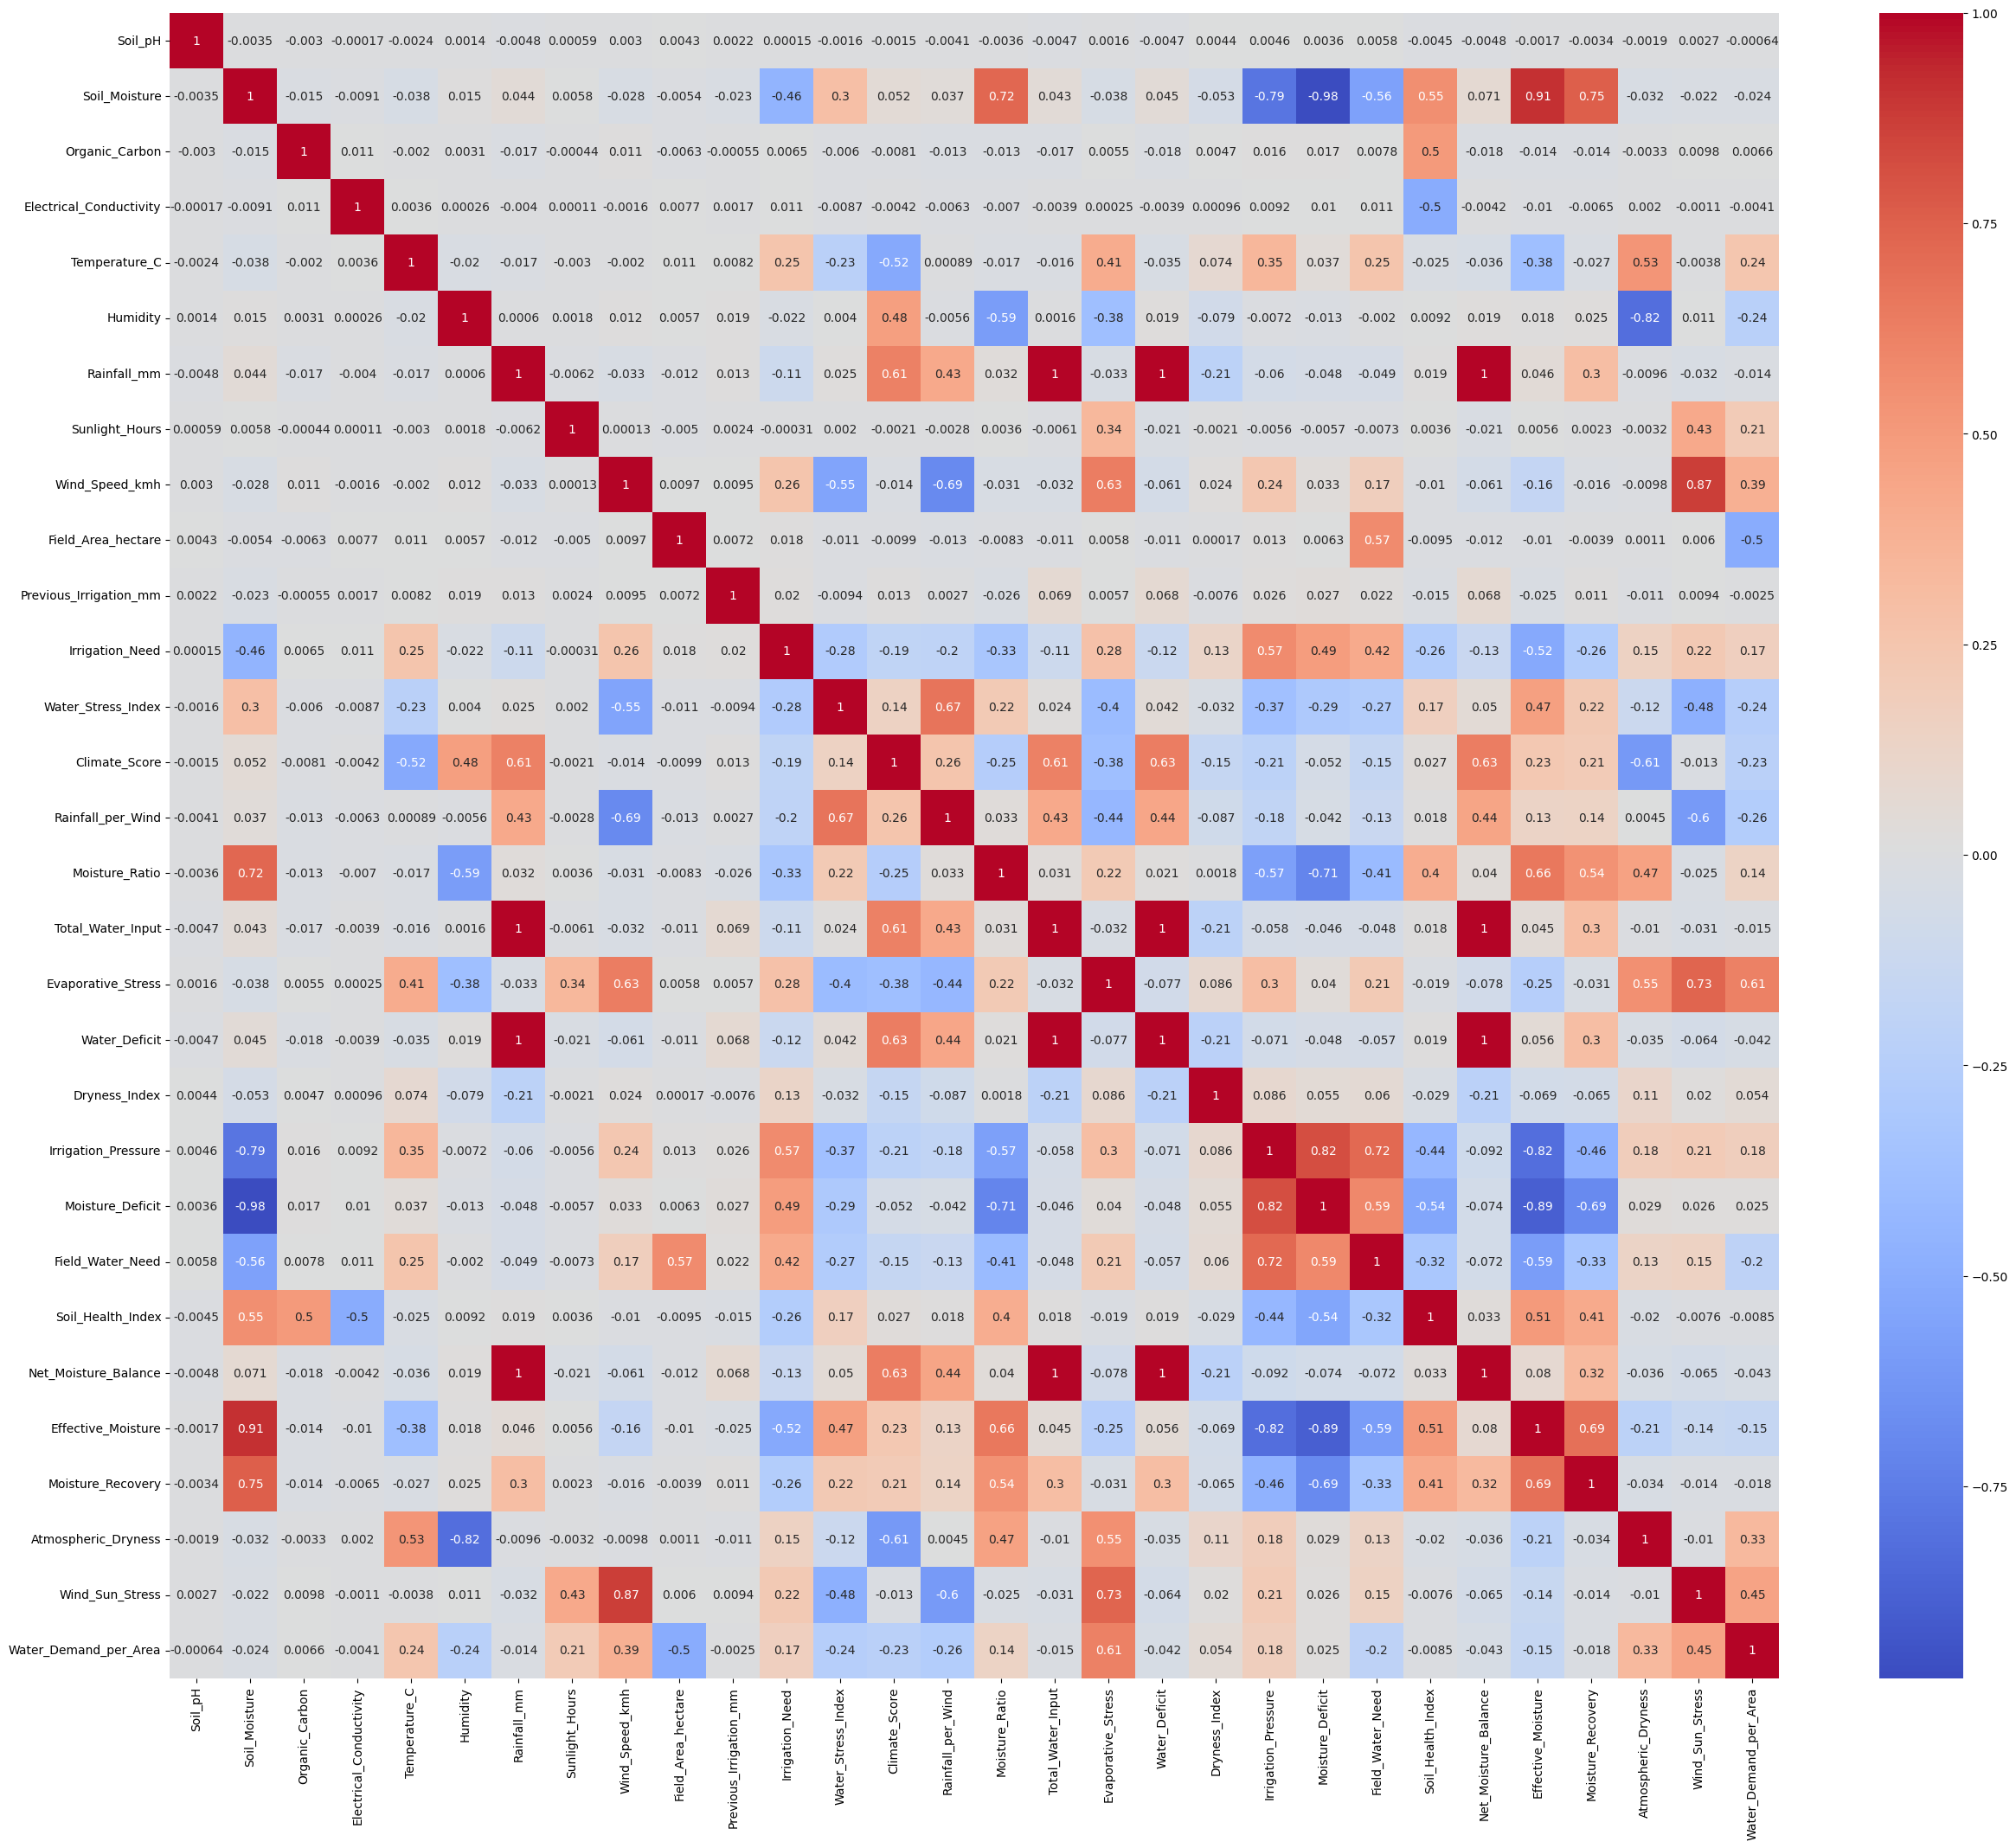

In [204]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(30, 25))
sns.heatmap(correlation, annot=True, cmap='coolwarm')

### *Over Sampling the Imbalanced data*

In [205]:
smote = SMOTE(
    sampling_strategy='not majority',
    random_state=42
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Original training shape:", X_train.shape, y_train.shape)
print("After SMOTE shape:", X_train_res.shape, y_train_res.shape)
print("Training class distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())

Original training shape: (504000, 37) (504000,)
After SMOTE shape: (888540, 37) (888540,)
Training class distribution after SMOTE:
Irrigation_Need
0    296180
2    296180
1    296180
Name: count, dtype: int64


### *Using Class_Weight to handle the OverSampling*

In [206]:
# Class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_res),
    y=y_train_res
)

class_weights = dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


In [207]:
num_classes = len(np.unique(y))

y_train_res_cat = to_categorical(y_train_res, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

### *Try to Reduce the Loss*

In [208]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-8, 1.0)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
    return loss

# *Deep Learning Model* 

In [296]:
model=Sequential([
    Dense(128 , activation="relu" , input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64 , activation= "relu"),
    Dense(64 , activation= "relu"),

    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32 , activation='relu'),
    Dense(3,activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_118 (Dense)               │ (None, 128)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_120 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_122 (Dense)               │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,227 (79.01 KB)

 Trainable params: 19,843 (77.51 KB)

 Non-trainable params: 384 (1.50 KB)

In [297]:
model.compile(optimizer=Adam(learning_rate=0.0001),
             loss=focal_loss(gamma=2.0, alpha=0.25),
            metrics=['accuracy'])

early_stopping=EarlyStopping(
                patience=10,
                monitor='val_loss')

In [299]:
model.fit(
    X_train_res,
    y_train_res_cat,
    validation_data=(X_test, y_test_cat),
    epochs=100,
    batch_size=128,
    class_weight=class_weights,
    callbacks=[early_stopping]
    )

In [294]:
y_pred_train = model.predict(X_train)
y_pred_test= model.predict(X_test)

15750/15750 ━━━━━━━━━━━━━━━━━━━━ 21s 1ms/step
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


### *Using The Balanced Accuracy*

In [300]:
from sklearn.metrics import balanced_accuracy_score

    
balanced_accuracy_score(y_pred_train.argmax(axis=1), y_train), balanced_accuracy_score(y_pred_test.argmax(axis=1), y_test)

### *Predict the Test file and Convert the data into Main classes ("Low", "Medium", "High")*

In [282]:
preds = model.predict(df_test)

8438/8438 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


In [283]:
import numpy as np
mapinig = {0: "Low", 1: "Medium", 2: "High"}
sub['Irrigation_Need'] = preds.argmax(axis=1)
sub['Irrigation_Need'] = sub['Irrigation_Need'].map(mapinig)
sub

/tmp/ipykernel_56/2001176221.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['Irrigation_Need'] = preds.argmax(axis=1)
/tmp/ipykernel_56/2001176221.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['Irrigation_Need'] = sub['Irrigation_Need'].map(mapinig)


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
...,...,...
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low


In [284]:
sub.to_csv("sub24.csv", index=False)